# Importing Python libraries

In [ ]:
# importing libraries for data handling and analysis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# sklearn modules for preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV

# Libraries for data modelling
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Common sklearn Model Helpers
from sklearn import model_selection, metrics

# sklearn modules for performance metrics
from sklearn.metrics import (classification_report, roc_auc_score, recall_score,
f1_score, accuracy_score, precision_score)

# Importing the data

In [ ]:
# Read Excel file
df_HR = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

df_HR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

> The data provided has no missing values.

# Exploratory Data Analysis

### Check for duplicates

In [ ]:
print(f'Number of duplicate rows: {df_HR.duplicated().sum()}')

Number of duplicate rows: 0


### Numerical features overview

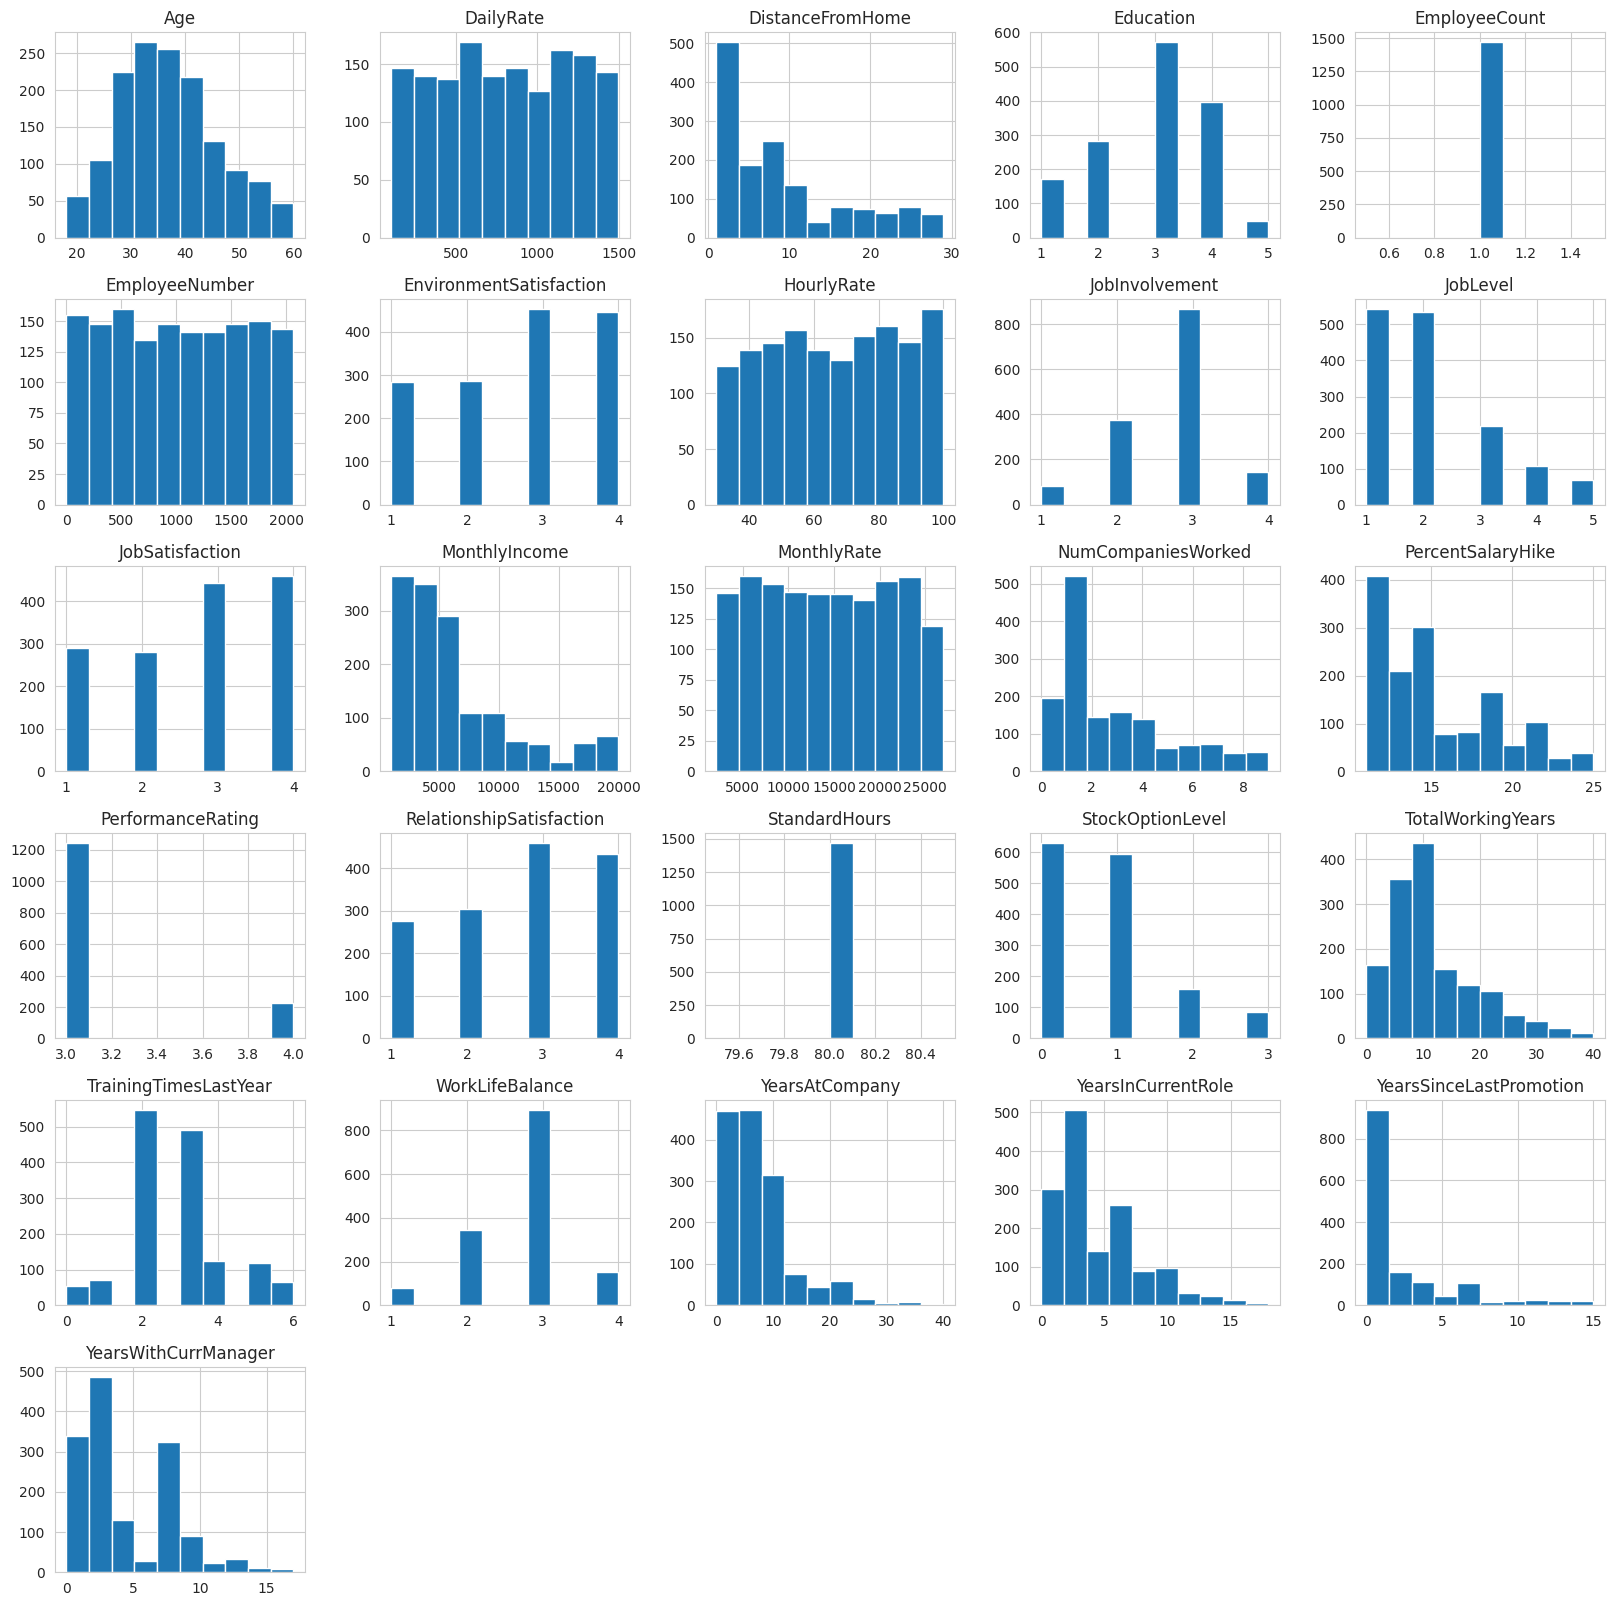

In [ ]:
df_HR.hist(figsize=(20,20))
plt.show()

> A few observations can be made based on the histogram:
 - Many histograms are right-skewed (e.g. MonthlyIncome DistanceFromHome, YearsAtCompany).
 - EmployeeCount and StandardHours are constant values for all employees. They are redundant features.
 - Employee Number is likely a unique identifier for employees given the feature's quasi-uniform distribution.

### Exploring Attrition (Target Variable)

In [ ]:
# Attrition indicates if the employee is currently active ('No') or has left the company ('Yes')
df_HR['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [ ]:
print("Percentage of Current Employees is {:.1f}% and of Ex-employees is: {:.1f}%".format(
    df_HR[df_HR['Attrition'] == 'No'].shape[0] / df_HR.shape[0]*100,
    df_HR[df_HR['Attrition'] == 'Yes'].shape[0] / df_HR.shape[0]*100))

Percentage of Current Employees is 83.9% and of Ex-employees is: 16.1%


/tmp/ipython-input-421524213.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df_HR, palette='viridis')


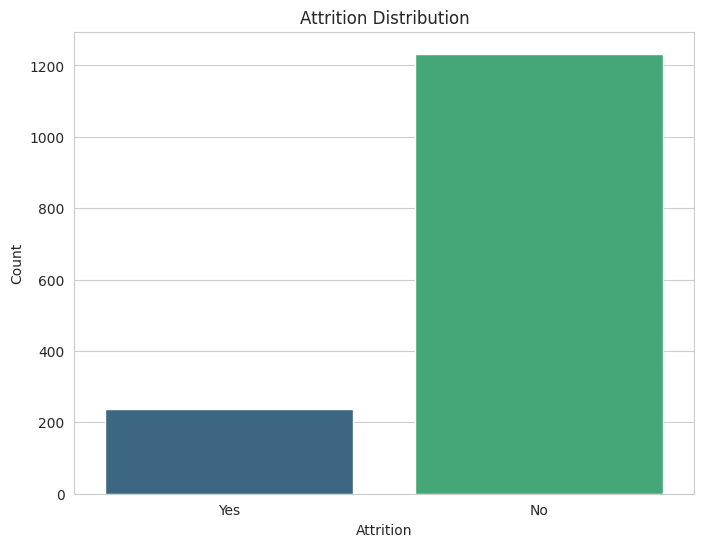

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Attrition', data=df_HR, palette='viridis')
plt.title('Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

> As shown on the chart above, this is an imbalanced class problem.

### Numerical Correlation

In [ ]:
# Find correlations with the target and sort
df_HR_trans = df_HR.copy()
df_HR_trans['Target'] = df_HR_trans['Attrition'].apply(
    lambda x: 0 if x == 'No' else 1)
df_HR_trans = df_HR_trans.drop(
    ['Attrition', 'EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'], axis=1)
correlations = df_HR_trans.corr(numeric_only=True)['Target'].sort_values()
print('Most Positive Correlations: \n', correlations[correlations.index != 'Target'].tail(3))
print('\nMost Negative Correlations: \n', correlations.head(3))

Most Positive Correlations: 
 MonthlyRate           0.015170
NumCompaniesWorked    0.043494
DistanceFromHome      0.077924
Name: Target, dtype: float64

Most Negative Correlations: 
 TotalWorkingYears    -0.171063
JobLevel             -0.169105
YearsInCurrentRole   -0.160545
Name: Target, dtype: float64


<Axes: >

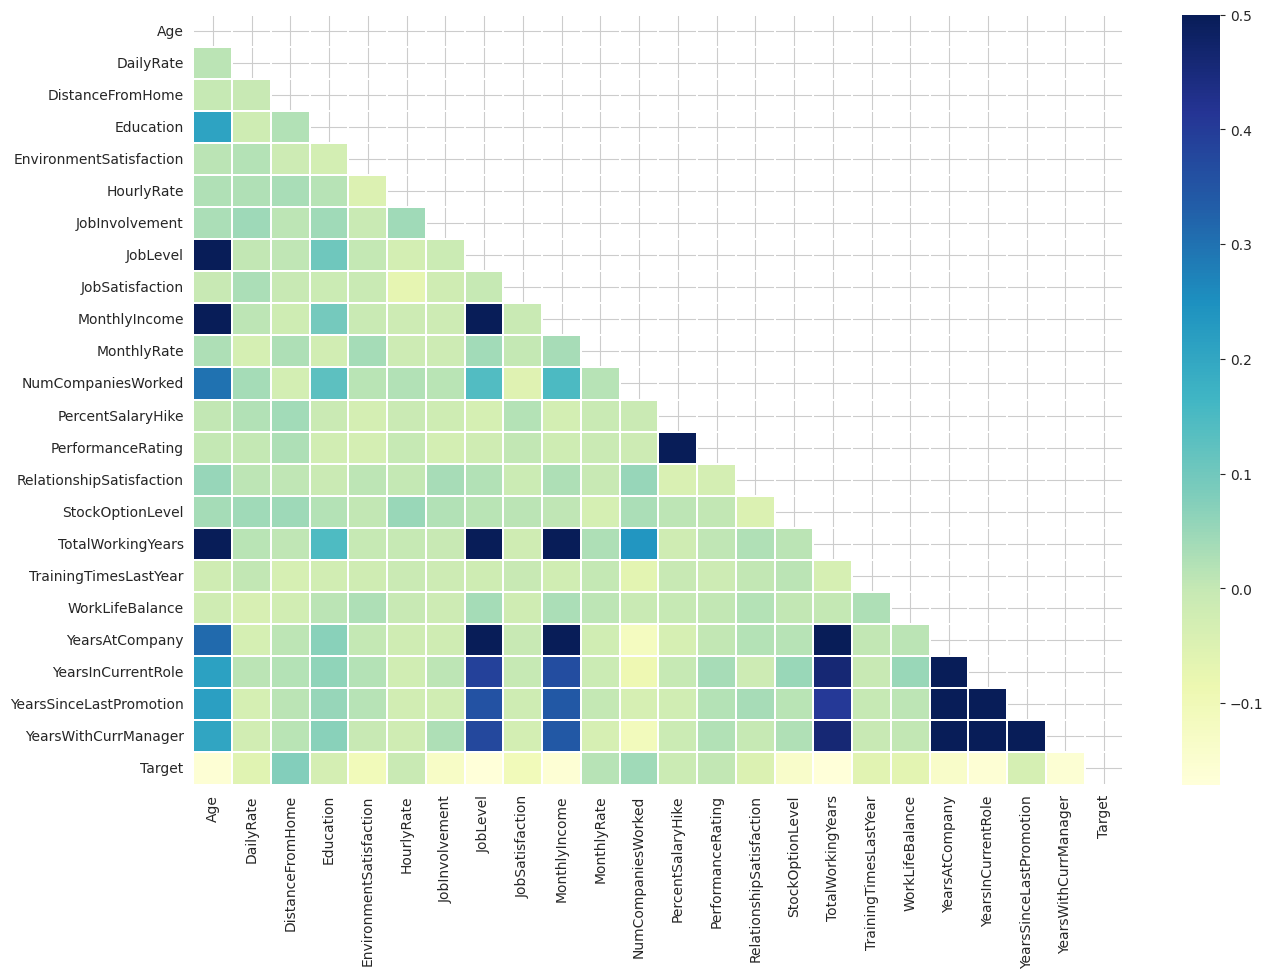

In [ ]:
# Calculate correlations
corr = df_HR_trans.corr(numeric_only=True)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
# Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr,
            vmax=.5,
            mask=mask,
            linewidths=.2, cmap="YlGnBu")

> As shown above, "Monthly Rate", "Number of Companies Worked" and "Distance From Home" are positively correlated to Attrition while "Total Working Years", "Job Level", and "Years In Current Role" are negatively correlated to Attrition.

### Categorical Correlation

In [ ]:
from scipy.stats import chi2_contingency

original_categorical_features = [
    'BusinessTravel', 'Department', 'EducationField', 'Gender',
    'JobRole', 'MaritalStatus', 'OverTime'
]

associations = {}

for feature in original_categorical_features:
    contingency_table = pd.crosstab(df_HR_trans[feature], df_HR_trans['Target'])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    cramers_v = np.sqrt(phi2 / min(k-1, r-1))

    associations[feature] = {
        'Chi2': chi2,
        'P_Value': p_value,
        'Cramers_V': cramers_v,
        'n_categories': r
    }

assoc_df = pd.DataFrame(associations).T.sort_values('Cramers_V', ascending=False)
print("Association Between Categorical Features and Target:")
print(assoc_df)

Association Between Categorical Features and Target:
                     Chi2       P_Value  Cramers_V  n_categories
OverTime        87.564294  8.158424e-21   0.244065           2.0
JobRole         86.190254  2.752482e-15   0.242142           9.0
MaritalStatus   46.163677  9.455511e-11   0.177211           3.0
BusinessTravel  24.182414  5.608614e-06   0.128260           3.0
EducationField  16.024674  6.773980e-03   0.104409           6.0
Department      10.796007  4.525607e-03   0.085698           3.0
Gender           1.116967  2.905724e-01   0.027565           2.0


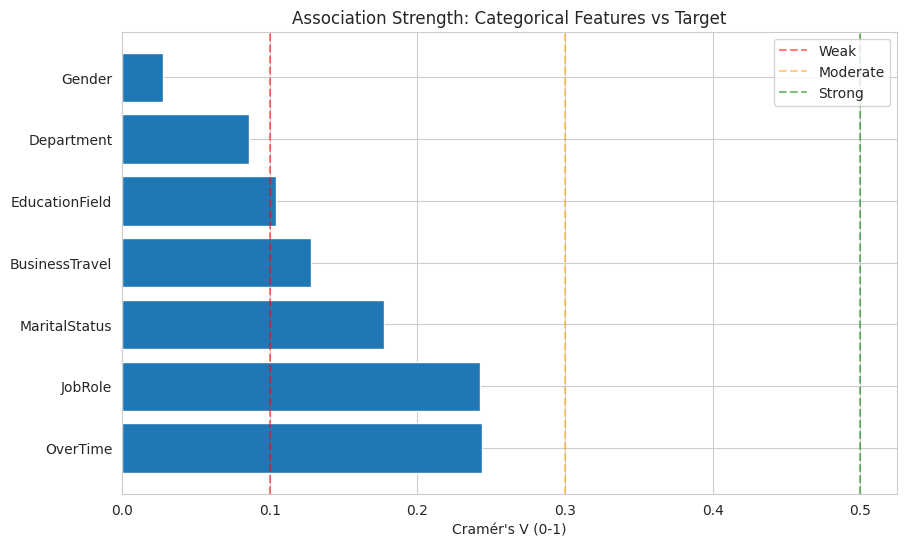

In [ ]:
cramers_values = assoc_df['Cramers_V']
plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(cramers_values)), cramers_values.sort_values())
plt.yticks(range(len(cramers_values)), cramers_values.sort_values().index)
plt.xlabel("Cramér's V (0-1)")
plt.title('Association Strength: Categorical Features vs Target')
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Weak')
plt.axvline(x=0.3, color='orange', linestyle='--', alpha=0.5, label='Moderate')
plt.axvline(x=0.5, color='green', linestyle='--', alpha=0.5, label='Strong')
plt.legend()
plt.gca().invert_yaxis()
plt.show()

### Top Numerical Feature distribution by target attribute

#### Positive Correlation


> Distance from Home

In [ ]:
# Distance from Home
print("Distance from home for employees to get to work is from {} to {} miles.".format(df_HR['DistanceFromHome'].min(),
                                                                                       df_HR['DistanceFromHome'].max()))
print('Average distance from home for currently active employees: {:.2f} miles and ex-employees: {:.2f} miles'.format(
    df_HR[df_HR['Attrition'] == 'No']['DistanceFromHome'].mean(), df_HR[df_HR['Attrition'] == 'Yes']['DistanceFromHome'].mean()))

Distance from home for employees to get to work is from 1 to 29 miles.
Average distance from home for currently active employees: 8.92 miles and ex-employees: 10.63 miles


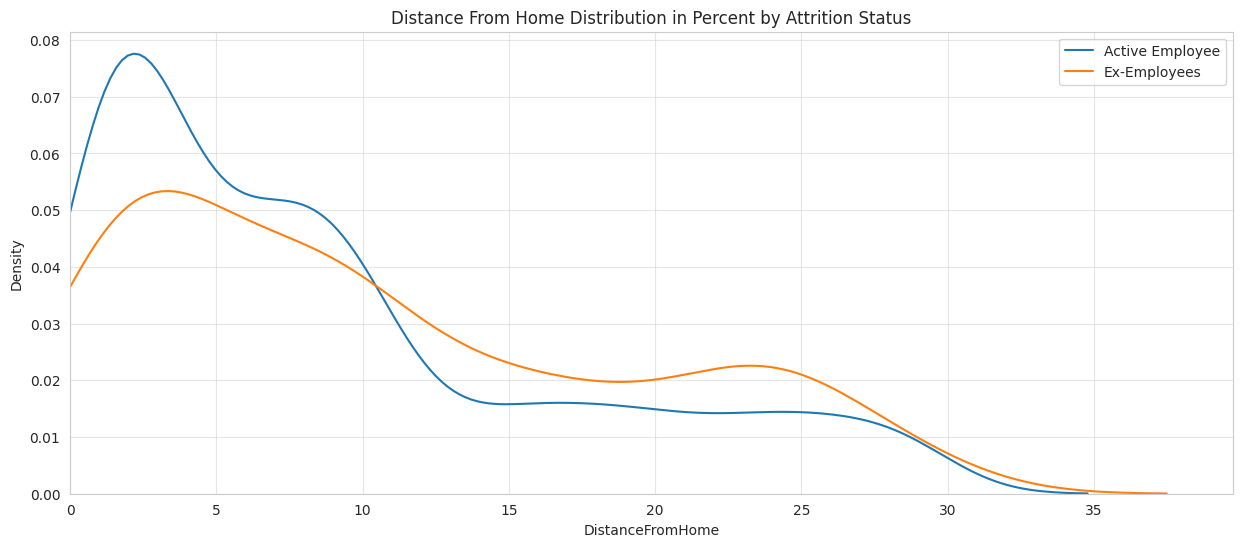

In [ ]:
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')
plt.grid(True, alpha=0.5)
sns.kdeplot(df_HR.loc[df_HR['Attrition'] == 'No', 'DistanceFromHome'], label = 'Active Employee')
sns.kdeplot(df_HR.loc[df_HR['Attrition'] == 'Yes', 'DistanceFromHome'], label = 'Ex-Employees')
plt.xlabel('DistanceFromHome')
plt.xlim(left=0)
plt.ylabel('Density')
plt.title('Distance From Home Distribution in Percent by Attrition Status');
plt.legend()

> Number of Companies Worked

In [ ]:
df_HR['NumCompaniesWorked'].value_counts()

,count
NumCompaniesWorked,
1,521
0,197
3,159
2,146
4,139
7,74
6,70
5,63
9,52


<Figure size 1000x600 with 0 Axes>

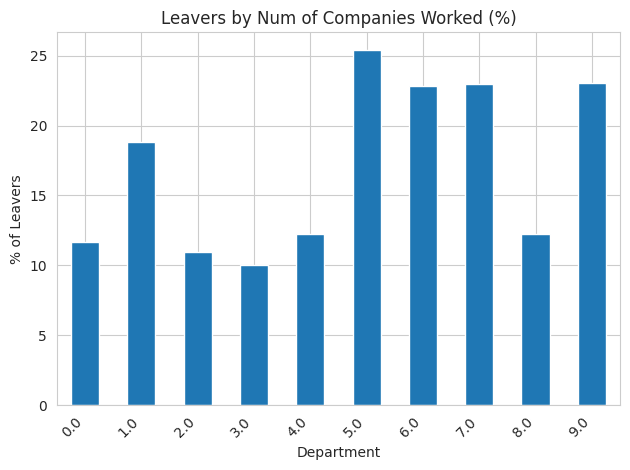

In [ ]:
df_NumCompaniesWorked = pd.DataFrame(columns=["Num Companies Worked", "% of Leavers"])
i=0
for field in list(df_HR['NumCompaniesWorked'].unique()):
    ratio = df_HR[(df_HR['NumCompaniesWorked']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['NumCompaniesWorked']==field].shape[0]
    df_NumCompaniesWorked.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))
df_NC = df_NumCompaniesWorked.groupby(by="Num Companies Worked").sum()

plt.figure(figsize=(10, 6))
df_NC.plot(kind='bar', title='Leavers by Num of Companies Worked (%)', legend=False)
plt.ylabel('% of Leavers')
plt.xlabel('Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> Monthly Rate


In [ ]:
print("Employee Monthly Rate varies from ${} to ${}.".format(
    df_HR['MonthlyRate'].min(), df_HR['MonthlyRate'].max()))

Employee Monthly Rate varies from $2094 to $26999.


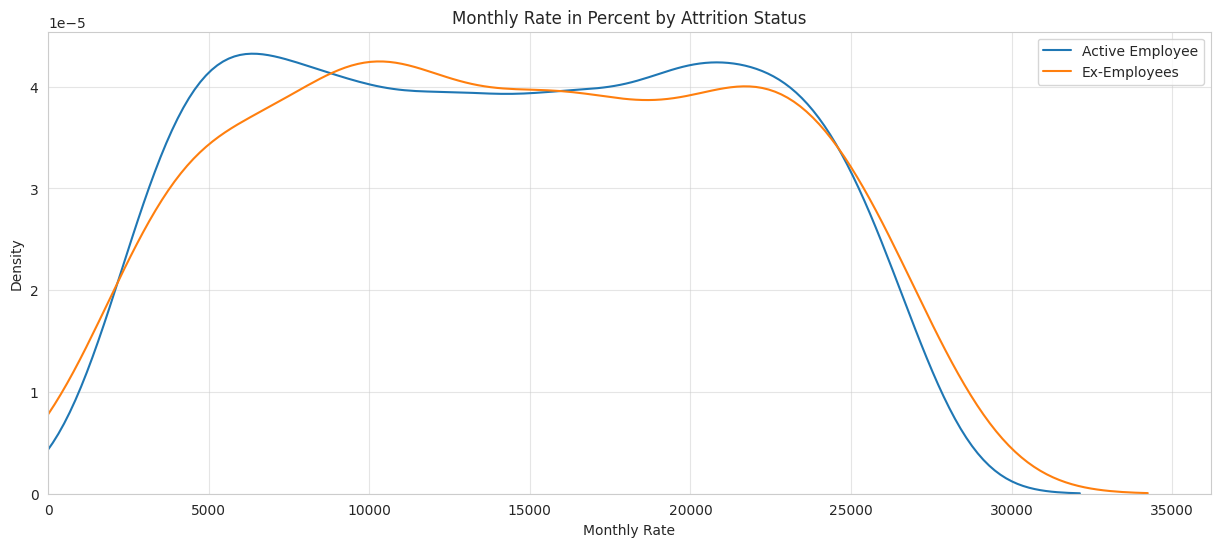

In [ ]:
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')
plt.grid(True, alpha=0.5)
sns.kdeplot(df_HR.loc[df_HR['Attrition'] == 'No', 'MonthlyRate'], label = 'Active Employee')
sns.kdeplot(df_HR.loc[df_HR['Attrition'] == 'Yes', 'MonthlyRate'], label = 'Ex-Employees')
plt.xlabel('Monthly Rate')
plt.xlim(left=0)
plt.ylabel('Density')
plt.title('Monthly Rate in Percent by Attrition Status')
plt.legend()

#### Negative Correlation

> Total Working Years

In [ ]:
print("Total working years varies from {} to {} years.".format(
    df_HR['TotalWorkingYears'].min(), df_HR['TotalWorkingYears'].max()))

Total working years varies from 0 to 40 years.


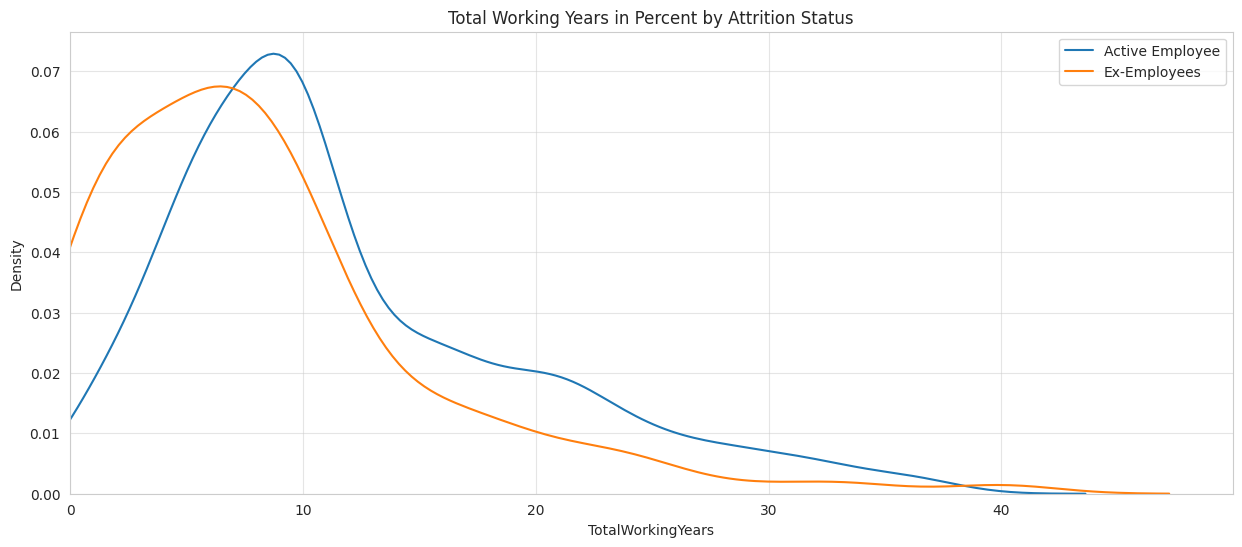

In [ ]:
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')
plt.grid(True, alpha=0.5)
sns.kdeplot(df_HR.loc[df_HR['Attrition'] == 'No', 'TotalWorkingYears'], label = 'Active Employee')
sns.kdeplot(df_HR.loc[df_HR['Attrition'] == 'Yes', 'TotalWorkingYears'], label = 'Ex-Employees')
plt.xlabel('TotalWorkingYears')
plt.xlim(left=0)
plt.ylabel('Density')
plt.title('Total Working Years in Percent by Attrition Status')
plt.legend()

> Job Level

In [ ]:
df_HR['JobLevel'].value_counts()

,count
JobLevel,
1,543
2,534
3,218
4,106
5,69


<Figure size 1000x600 with 0 Axes>

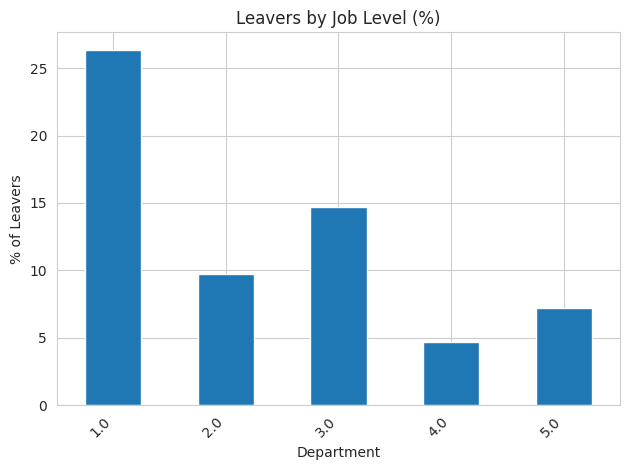

In [ ]:
df_JobLevel = pd.DataFrame(columns=["Job Level", "% of Leavers"])
i=0
for field in list(df_HR['JobLevel'].unique()):
    ratio = df_HR[(df_HR['JobLevel']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['JobLevel']==field].shape[0]
    df_JobLevel.loc[i] = (field, ratio*100)
    i += 1
df_JL = df_JobLevel.groupby(by="Job Level").sum()

plt.figure(figsize=(10, 6))
df_JL.plot(kind='bar', title='Leavers by Job Level (%)', legend=False)
plt.ylabel('% of Leavers')
plt.xlabel('Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> Years in Current Role

In [ ]:
print("Number of Years in the current role varies from {} to {} years.".format(
    df_HR['YearsInCurrentRole'].min(), df_HR['YearsInCurrentRole'].max()))

Number of Years in the current role varies from 0 to 18 years.


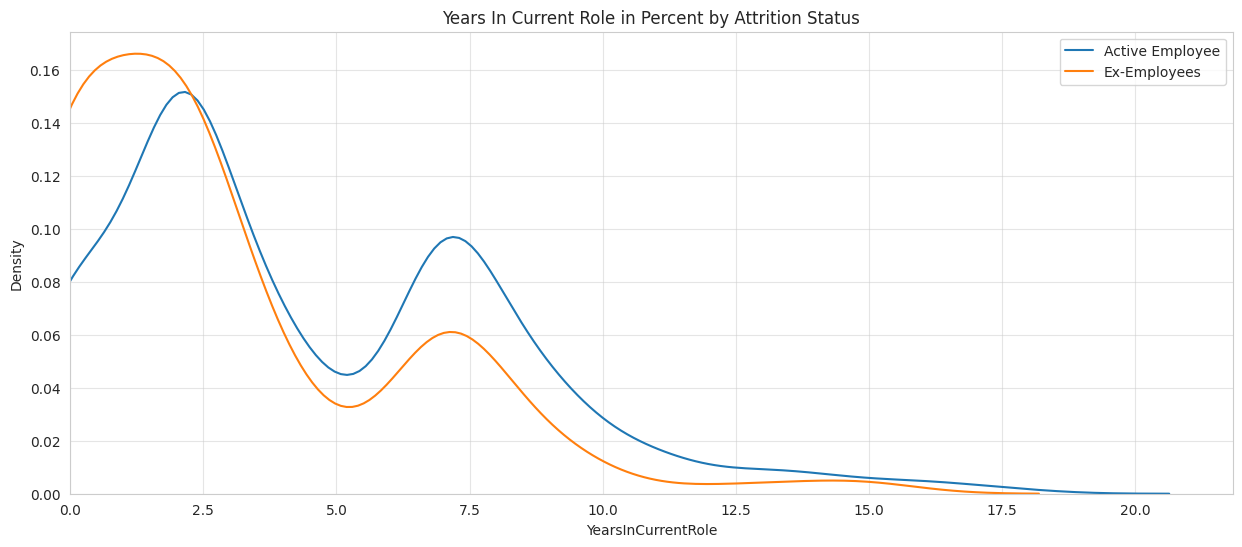

In [ ]:
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')
plt.grid(True, alpha=0.5)
sns.kdeplot(df_HR.loc[df_HR['Attrition'] == 'No', 'YearsInCurrentRole'], label = 'Active Employee')
sns.kdeplot(df_HR.loc[df_HR['Attrition'] == 'Yes', 'YearsInCurrentRole'], label = 'Ex-Employees')
plt.xlabel('YearsInCurrentRole')
plt.xlim(left=0)
plt.ylabel('Density')
plt.title('Years In Current Role in Percent by Attrition Status')
plt.legend()

### Top Categorical Feature distribution by target attribute

> Overtime

In [ ]:
df_HR['OverTime'].value_counts()

,count
OverTime,
No,1054
Yes,416


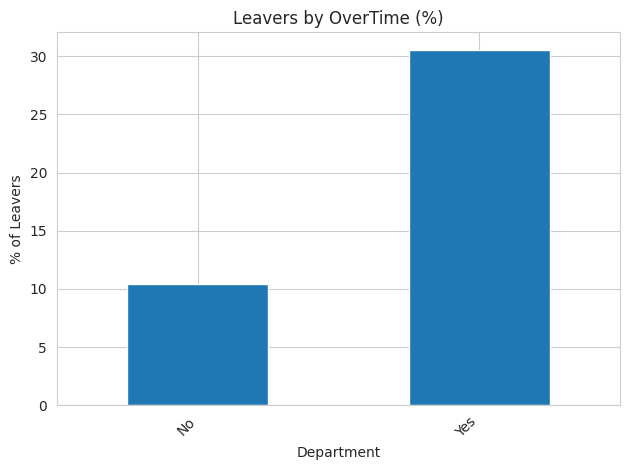

In [ ]:
df_OverTime = pd.DataFrame(columns=["OverTime", "% of Leavers"])
i=0
for field in list(df_HR['OverTime'].unique()):
    ratio = df_HR[(df_HR['OverTime']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['OverTime']==field].shape[0]
    df_OverTime.loc[i] = (field, ratio*100)
    i += 1
df_OT = df_OverTime.groupby(by="OverTime").sum()

df_OT.plot(kind='bar', title='Leavers by OverTime (%)', legend=False)
plt.ylabel('% of Leavers')
plt.xlabel('Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> Job Role

In [ ]:
# Employees in the database have several roles on-file
df_HR['JobRole'].value_counts()

,count
JobRole,
Sales Executive,326
Research Scientist,292
Laboratory Technician,259
Manufacturing Director,145
Healthcare Representative,131
Manager,102
Sales Representative,83
Research Director,80
Human Resources,52


<Figure size 1000x600 with 0 Axes>

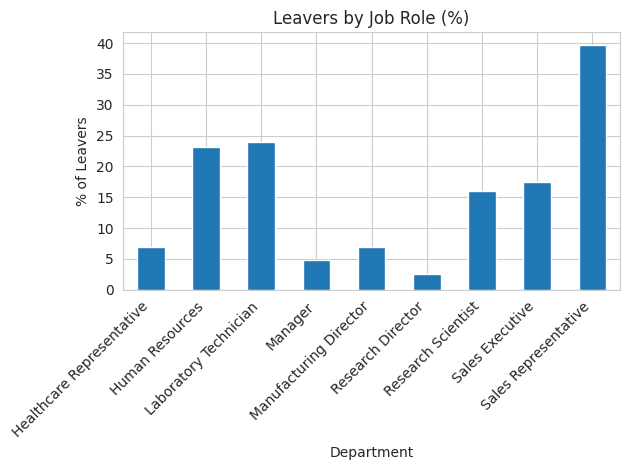

In [ ]:
df_JobRole = pd.DataFrame(columns=["Job Role", "% of Leavers"])
i=0
for field in list(df_HR['JobRole'].unique()):
    ratio = df_HR[(df_HR['JobRole']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['JobRole']==field].shape[0]
    df_JobRole.loc[i] = (field, ratio*100)
    i += 1
df_JR = df_JobRole.groupby(by="Job Role").sum()

plt.figure(figsize=(10, 6))
df_JR.plot(kind='bar', title='Leavers by Job Role (%)', legend=False)
plt.ylabel('% of Leavers')
plt.xlabel('Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### EDA Concluding Remarks

- The dataset does not feature any missing or erroneous data values, and all features are of the correct data type. <br>
- The strongest positive correlations with the target features are: **Monthly Rate**, **Num Companies Worked**, **Distance From Home**.
- The strongest negative correlations with the target features are: **Total Working Years**, **Job Level**, and **Years In Current Role**
- The dataset is **imbalanced** with the majoriy of observations describing Currently Active Employees.
- Several features (ie columns) are redundant for our analysis, namely: EmployeeCount, EmployeeNumber, StandardHours, and Over18.

# Pre-processing

### Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
print(df_HR.shape)
df_HR.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df_HR['BusinessTravel'] = df_HR['BusinessTravel'].map({
    'Non-Travel': 0,
    'Travel_Rarely': 1,
    'Travel_Frequently': 2
})

df_HR['Attrition'] = df_HR['Attrition'].map({
    'No': 0,
    'Yes': 1
})

df_HR['OverTime'] = df_HR['OverTime'].map({
    'No': 0,
    'Yes': 1
})

In [ ]:
# convert rest of categorical variable into dummy
df_HR = pd.get_dummies(df_HR, drop_first=True)

In [ ]:
print(df_HR.shape)
df_HR.head()

(1470, 47)


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,1102,1,2,1,1,2,94,...,False,False,False,False,False,False,True,False,False,True
1,49,0,2,279,8,1,1,2,3,61,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1,1373,2,2,1,4,4,92,...,False,True,False,False,False,False,False,False,False,True
3,33,0,2,1392,3,4,1,5,4,56,...,False,False,False,False,False,True,False,False,True,False
4,27,0,1,591,2,1,1,7,1,40,...,False,True,False,False,False,False,False,False,True,False


> The resulting dataframe has **47 columns** for 1,470 employees.

### Feature Scaling

In [ ]:
# import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 5))
HR_col = list(df_HR.columns)
HR_col.remove('Attrition')
for col in HR_col:
    df_HR[col] = df_HR[col].astype(float)
    df_HR[[col]] = scaler.fit_transform(df_HR[[col]])
df_HR['Attrition'] = pd.to_numeric(df_HR['Attrition'], downcast='float')
df_HR.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,2.738095,1.0,2.5,3.579098,0.000000,1.25,0.0,0.000000,1.666667,4.571429,...,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,5.0
1,3.690476,0.0,5.0,0.633500,1.250000,0.00,0.0,0.002419,3.333333,2.214286,...,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,5.0,0.0
2,2.261905,1.0,2.5,4.549034,0.178571,1.25,0.0,0.007257,5.000000,4.428571,...,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
3,1.785714,0.0,5.0,4.617037,0.357143,3.75,0.0,0.009676,5.000000,1.857143,...,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,5.0,0.0
4,1.071429,0.0,2.5,1.750179,0.178571,0.00,0.0,0.014514,0.000000,0.714286,...,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0


### Splitting data into training and testing sets

In [ ]:
# assign the target to a new dataframe and convert it to a numerical feature
target = df_HR['Attrition'].copy()

In [ ]:
# let's remove the target feature and redundant features from the dataset
df_HR.drop(['Attrition', 'EmployeeCount', 'EmployeeNumber',
            'StandardHours'], axis=1, inplace=True)
print('Size of Full dataset is: {}'.format(df_HR.shape))

Size of Full dataset is: (1470, 43)


In [ ]:
# Since we have class imbalance (i.e. more employees with turnover=0 than turnover=1)
# let's use stratify=y to maintain the same ratio as in the training dataset when splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(df_HR,
                                                    target,
                                                    test_size=0.25,
                                                    random_state=7,
                                                    stratify=target)
print("Number transactions X_train dataset: ", X_train.shape)
print("Number transactions y_train dataset: ", y_train.shape)
print("Number transactions X_test dataset: ", X_test.shape)
print("Number transactions y_test dataset: ", y_test.shape)

Number transactions X_train dataset:  (1102, 43)
Number transactions y_train dataset:  (1102,)
Number transactions X_test dataset:  (368, 43)
Number transactions y_test dataset:  (368,)


# Building Machine Learning Models

### Baseline Algorithms

In [ ]:
# selection of algorithms to consider and set performance measure
models = []
models.append(('Logistic Regression', LogisticRegression(solver='liblinear', random_state=7,
                                                         class_weight='balanced')))
models.append(('Random Forest', RandomForestClassifier(
    n_estimators=100, random_state=7)))
models.append(('SVM', SVC(gamma='auto', random_state=7)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('Decision Tree Classifier',
               DecisionTreeClassifier(random_state=7)))
models.append(('Gaussian NB', GaussianNB()))

In [ ]:
acc_results = []
auc_results = []
names = []
# set table to table to populate with performance results
col = ['Algorithm', 'ROC AUC Mean', 'ROC AUC STD',
       'Accuracy Mean', 'Accuracy STD']
df_results = pd.DataFrame(columns=col)
i = 0
# evaluate each model using cross-validation
for name, model in models:
    kfold = model_selection.KFold(
        n_splits=10, random_state=7, shuffle=True)  # 10-fold cross-validation

    cv_acc_results = model_selection.cross_val_score(  # accuracy scoring
        model, X_train, y_train, cv=kfold, scoring='accuracy')

    cv_auc_results = model_selection.cross_val_score(  # roc_auc scoring
        model, X_train, y_train, cv=kfold, scoring='roc_auc')

    acc_results.append(cv_acc_results)
    auc_results.append(cv_auc_results)
    names.append(name)
    df_results.loc[i] = [name,
                         round(cv_auc_results.mean()*100, 2),
                         round(cv_auc_results.std()*100, 2),
                         round(cv_acc_results.mean()*100, 2),
                         round(cv_acc_results.std()*100, 2)
                         ]
    i += 1
df_results.sort_values(by=['ROC AUC Mean'], ascending=False)

,Algorithm,ROC AUC Mean,ROC AUC STD,Accuracy Mean,Accuracy STD
0,Logistic Regression,81.65,6.43,76.60,4.64
1,Random Forest,79.33,5.95,84.85,2.74
2,SVM,78.80,5.56,84.76,2.45
5,Gaussian NB,75.21,4.83,67.06,5.34
3,KNN,68.30,6.10,83.85,1.76
4,Decision Tree Classifier,64.65,6.59,79.95,4.66


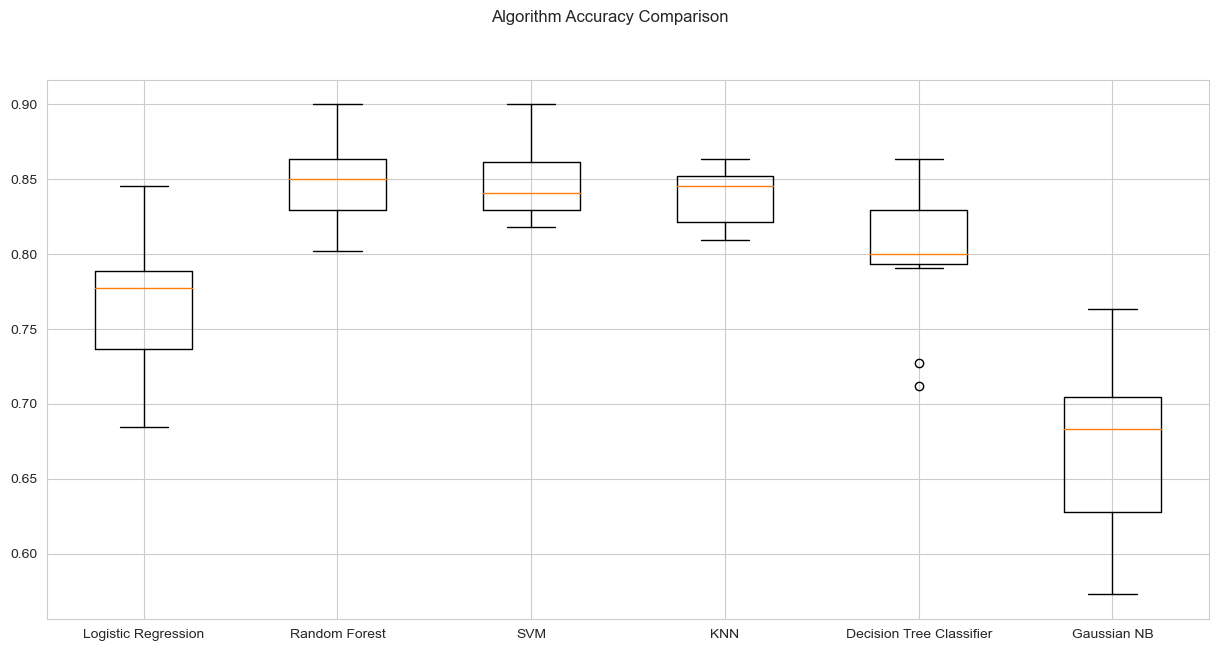

In [ ]:
fig = plt.figure(figsize=(15, 7))
fig.suptitle('Algorithm Accuracy Comparison')
ax = fig.add_subplot(111)
plt.boxplot(acc_results)
ax.set_xticklabels(names)
plt.show()

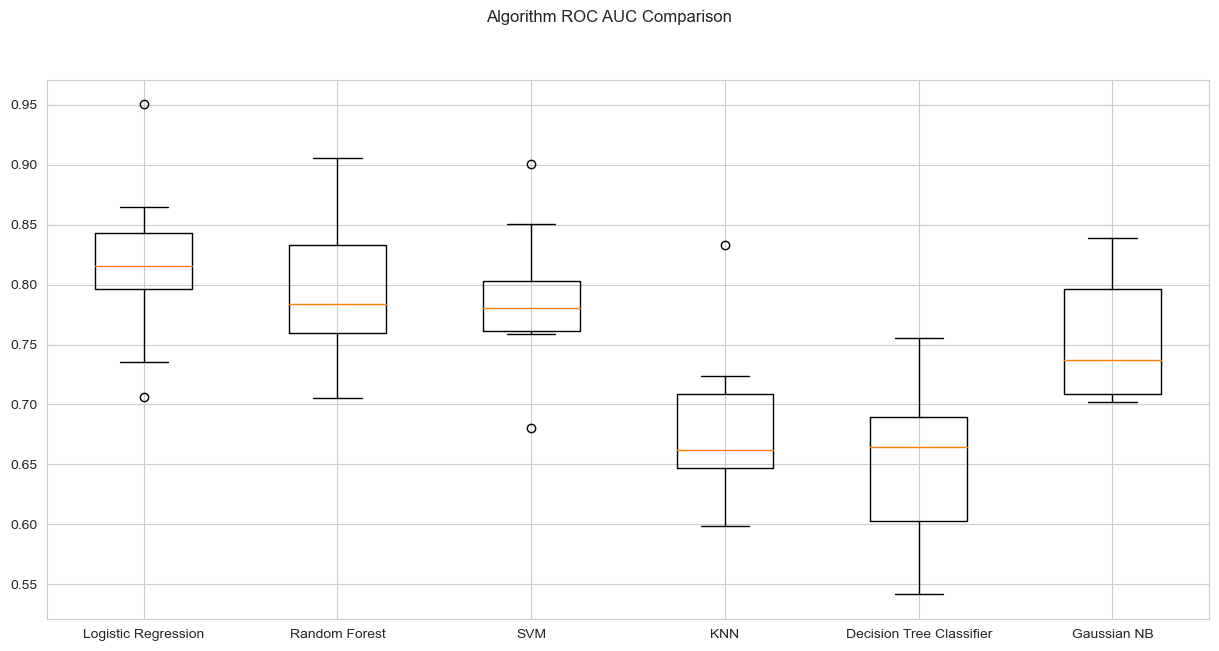

In [ ]:
fig = plt.figure(figsize=(15, 7))
fig.suptitle('Algorithm ROC AUC Comparison')
ax = fig.add_subplot(111)
plt.boxplot(auc_results)
ax.set_xticklabels(names)
plt.show()

> Based on our ROC AUC comparison analysis, **Logistic Regression** and **Random Forest** show the highest mean AUC scores. We will shortlist these two algorithms for further analysis.

### Logistic Regression

#### Fine-tuning

In [ ]:
param_grid = {'C': np.arange(1e-03, 2, 0.01)} # hyper-parameter list to fine-tune
log_gs = GridSearchCV(LogisticRegression(solver='liblinear', # setting GridSearchCV
                                         class_weight="balanced",
                                         random_state=7),
                      return_train_score=True,
                      param_grid=param_grid,
                      scoring='roc_auc',
                      cv=10)

log_grid = log_gs.fit(X_train, y_train)
log_opt = log_grid.best_estimator_
results = log_gs.cv_results_

print('='*20)
print("best params: " + str(log_gs.best_estimator_))
print("best params: " + str(log_gs.best_params_))
print('best score:', log_gs.best_score_)
print('='*20)

best params: LogisticRegression(C=np.float64(0.09099999999999998), class_weight='balanced',
                   random_state=7, solver='liblinear')
best params: {'C': np.float64(0.09099999999999998)}
best score: 0.816088545438434


#### Evaluation

Text(0.5, 427.9555555555555, 'Predicted label')

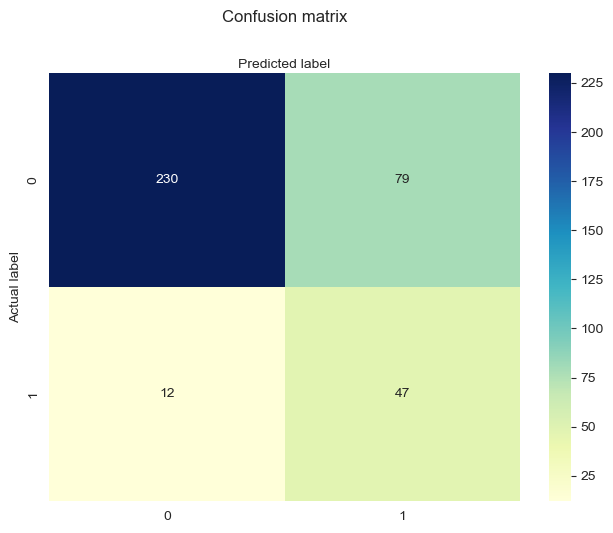

In [ ]:
## Confusion Matrix
cnf_matrix = metrics.confusion_matrix(y_test, log_opt.predict(X_test))
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [ ]:
# Classification report for the optimised Log Regression
log_opt.fit(X_train, y_train)
y_pred = log_opt.predict(X_test)
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

              precision    recall  f1-score   support

         0.0       0.95      0.74      0.83       309
         1.0       0.37      0.80      0.51        59

    accuracy                           0.75       368
   macro avg       0.66      0.77      0.67       368
weighted avg       0.86      0.75      0.78       368

Accuracy:  0.7527
Precision: 0.3730
Recall:    0.7966
F1 Score:  0.5081


In [ ]:
log_opt.fit(X_train, y_train) # fit optimised model to the training data
probs = log_opt.predict_proba(X_test) # predict probabilities
probs = probs[:, 1] # we will only keep probabilities associated with the employee leaving
logit_roc_auc = roc_auc_score(y_test, probs) # calculate AUC score using test dataset
print('AUC score: %.3f' % logit_roc_auc)

AUC score: 0.856


### Random Forest Classifier

#### Fine-tuning

In [ ]:
rf_classifier = RandomForestClassifier(class_weight = "balanced",
                                       random_state=7)
param_grid = {'n_estimators': [50, 75, 100, 125, 150, 175],
              'min_samples_split':[2,4,6,8,10],
              'min_samples_leaf': [1, 2, 3, 4],
              'max_depth': [5, 10, 15, 20, 25]}

grid_obj = GridSearchCV(rf_classifier,
                        return_train_score=True,
                        param_grid=param_grid,
                        scoring='roc_auc',
                        cv=10)

grid_fit = grid_obj.fit(X_train, y_train)
rf_opt = grid_fit.best_estimator_

print('='*20)
print("best params: " + str(grid_obj.best_estimator_))
print("best params: " + str(grid_obj.best_params_))
print('best score:', grid_obj.best_score_)
print('='*20)

best params: RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=4, min_samples_split=10,
                       n_estimators=50, random_state=7)
best params: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
best score: 0.7934523645830469


#### Evaluation

In [ ]:
## Confusion Matrix
cnf_matrix = metrics.confusion_matrix(y_test, rf_opt.predict(X_test))
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

NameError: name 'rf_opt' is not defined

In [ ]:
# Classification report for the optimised RF Regression
rf_opt.fit(X_train, y_train)
y_pred = rf_opt.predict(X_test)
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

              precision    recall  f1-score   support

         0.0       0.89      0.95      0.92       309
         1.0       0.58      0.37      0.45        59

    accuracy                           0.86       368
   macro avg       0.73      0.66      0.69       368
weighted avg       0.84      0.86      0.84       368

Accuracy:  0.8560
Precision: 0.5789
Recall:    0.3729
F1 Score:  0.4536


In [ ]:
rf_opt.fit(X_train, y_train) # fit optimised model to the training data
probs = rf_opt.predict_proba(X_test) # predict probabilities
probs = probs[:, 1] # we will only keep probabilities associated with the employee leaving
rf_opt_roc_auc = roc_auc_score(y_test, probs) # calculate AUC score using test dataset
print('AUC score: %.3f' % rf_opt_roc_auc)

AUC score: 0.826


#### Feature importance

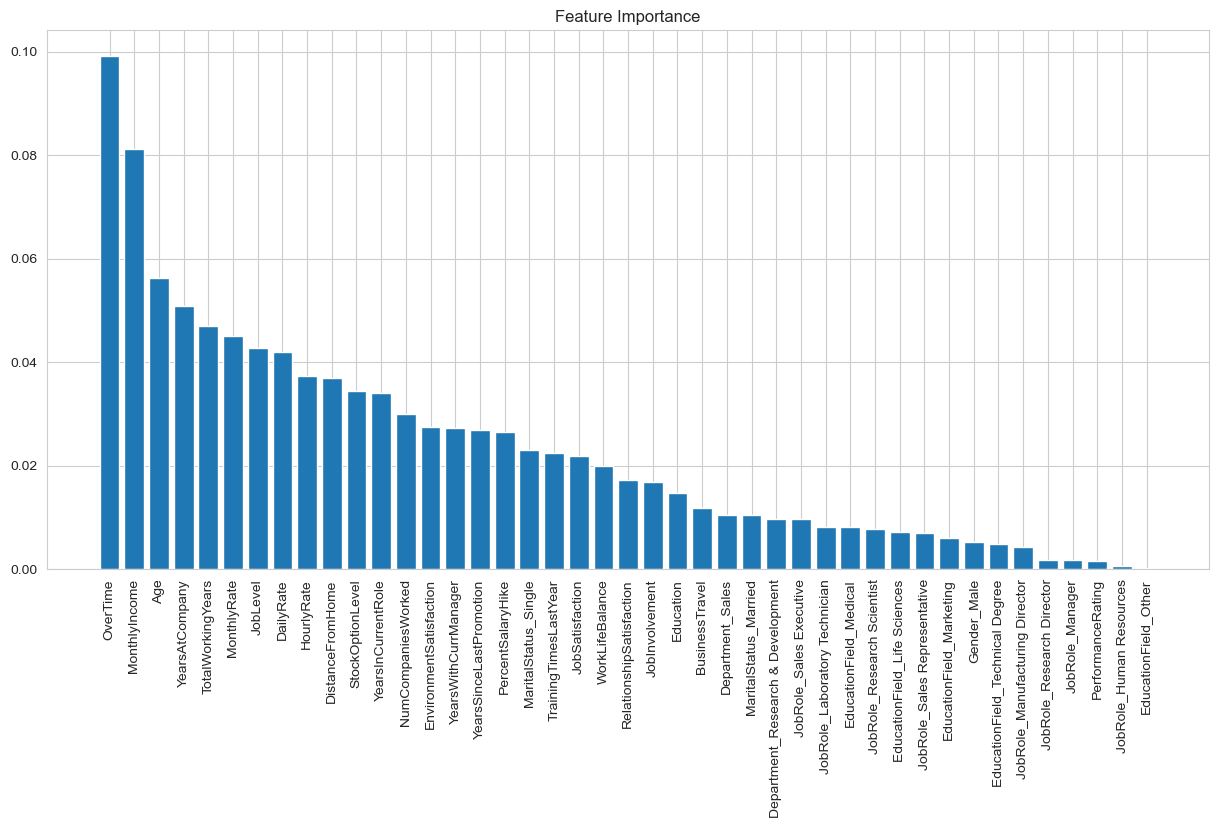

In [ ]:
importances = rf_opt.feature_importances_
indices = np.argsort(importances)[::-1]
names = [X_train.columns[i] for i in indices]
plt.figure(figsize=(15, 7))
plt.title("Feature Importance")
plt.bar(range(X_train.shape[1]), importances[indices])
plt.xticks(range(X_train.shape[1]), names, rotation=90)
plt.show() # Show plot

In [ ]:
importances = rf_opt.feature_importances_
df_param_coeff = pd.DataFrame(columns=['Feature', 'Coefficient'])
for i in range(43):
    feat = X_train.columns[i]
    coeff = importances[i]
    df_param_coeff.loc[i] = (feat, coeff)
df_param_coeff.sort_values(by='Coefficient', ascending=False, inplace=True)
df_param_coeff = df_param_coeff.reset_index(drop=True)
df_param_coeff.head(10)

,Feature,Coefficient
0,OverTime,0.099183
1,MonthlyIncome,0.081206
2,Age,0.056352
3,YearsAtCompany,0.050959
4,TotalWorkingYears,0.047042
5,MonthlyRate,0.045168
6,JobLevel,0.042842
7,DailyRate,0.042091
8,HourlyRate,0.037381
9,DistanceFromHome,0.036902


# ROC Graphs

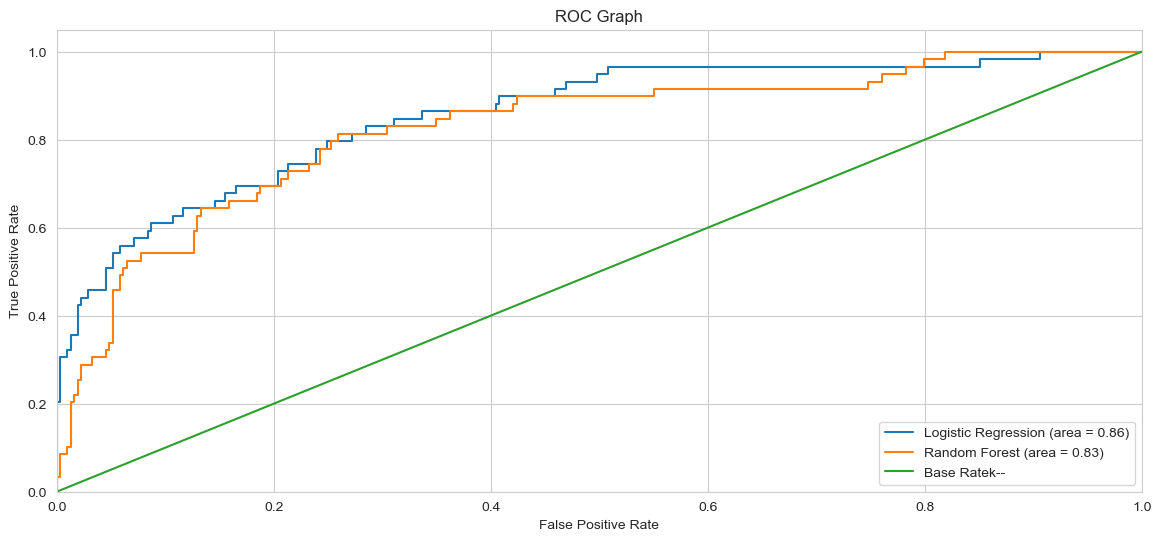

In [ ]:
# Create ROC Graph
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, log_opt.predict_proba(X_test)[:,1])
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_opt.predict_proba(X_test)[:,1])
plt.figure(figsize=(14, 6))

# Plot Logistic Regression ROC
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
# Plot Random Forest ROC
plt.plot(rf_fpr, rf_tpr, label='Random Forest (area = %0.2f)' % rf_opt_roc_auc)
# Plot Base Rate ROC
plt.plot([0,1], [0,1],label='Base Rate' 'k--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Graph')
plt.legend(loc="lower right")
plt.show()